# Week 6 - Neural Network I - Homework

This homework builds on the material in the notes on [neural networks](https://openlearninglibrary.mit.edu/courses/course-v1:MITx+6.036+1T2019/courseware/Week6/neural_networks/1) up through and including section 6 on loss functions.

In particular, in this homework we consider neural networks with multiple layers. Each layer has multiple inputs and outputs, and can be broken down into two parts:

- A **linear module** that implements a linear transformation:

  $$
  z_j = \left(\sum_{i=1}^{m} x_i w_{i,j}\right) + w_{0,j}
  $$

  specified by a weight matrix $W$ and a bias vector $W_0$. The output is

  $$
  [z_1,\ldots,z_n]^T.
  $$

- An **activation module** that applies an activation function to the outputs of the linear module for some activation function $f$, such as Tanh or ReLU in the hidden layers or Softmax (see below) at the output layer. We write the output as:

  $$
  [f(z_1),\ldots,f(z_n)]^T
  $$

  although technically, for some activation functions such as softmax, each output will depend on all the $z_i$, not just one.

We will use the following notation for quantities in a network:

- Inputs to the network are $x_1,\ldots,x_d$.
- Number of layers is $L$.
- There are $m^l$ inputs to layer $l$.
- There are $n^l = m^{l+1}$ outputs from layer $l$.
- The weight matrix for layer $l$ is $W^l$, an $m^l \times n^l$ matrix, and the bias vector (offset) is $W_0^l$, an $n^l \times 1$ vector.
- The outputs of the linear module for layer $l$ are known as **pre-activation values** and denoted $z^l$.
- The activation function at layer $l$ is $f^l(\cdot)$.
- Layer $l$ activations are

  $$
  a^l = [f^l(z_1^l),\ldots,f^l(z_{n^l}^l)]^T.
  $$

- The output of the network is the values

  $$
  a^L = [f^L(z_1^L),\ldots,f^L(z_{n^L}^L)]^T.
  $$

- Loss function $Loss(a,y)$ measures the loss of output values $a$ when the target is $y$.

## 1) Loss functions and output activations: classification

### 1.1) Hinge loss, linear activation

**1.1.A)** Write a short program to compute the gradient of the loss function with respect to the weight vector (not the bias): $\nabla_w L Loss(a_1^L,y)$ when $Loss(a,y)=L_h(ya)$.

In [1]:
import numpy as np

In [ ]:
def hinge_loss_grad(x, y, a):
  if y * a > 1:
    return np.zeros_like(x)
  
  return - y * a 

<div align="center">
    <img src="../assets/homeworks/1_1_1_A.png" alt="1_1_1_A" style="border-radius: 10px" />
</div>

### 1.2) Log loss, sigmoidal activation

1.2.A) What is an expression for the derivative of the sigmoid with respect to $z$, expressed as a function of $z$, its input?

$$
\frac{e^{-z}}{1+e^{-z}}
$$

<div align="center">
    <img src="../assets/homeworks/2_1_2_A.png" alt="2_1_2_A" style="border-radius: 10px" />
</div>

1.2.B) What is an expression for the derivative of the sigmoid with respect to $z$, but this time expressed as a function of $o=\sigma(z)$, its output?

Hint: Think about the expression

$$
1-\frac{1}{1+e^{-z}}
$$

$$
o - o^{2}
$$

<div align="center">
    <img src="../assets/homeworks/3_1_2_B.png" alt="3_1_2_B" style="border-radius: 10px" />
</div>

**In this model, we will consider positive points to have label +1, and negative points to have label 0**.

We need a loss function that works well when we are predicting probabilities. A good choice is to ask what probability is assigned to the correct label.

We will interpret the value outputted by our classifier as the probability that the example is positive. So, if the output value is $a$ and the true label is $+1$, then the probability assigned to the true label is $a$; on the other hand, if the true label is $0$, then the probability assigned to the true label is $1-a$.

Because we actually will be interested in the probability of the predictions on the whole data set, we'd want to choose weights to **maximize**

$$
\prod_t P(a^{(t)},y^{(t)})
$$

where $P(a^{(t)},y^{(t)})$ is the probability that the network predicts the correct label for data point $(t)$.

Using a notational trick (which turns an *if* expression into a product) that might seem unmotivated now, but will be useful later, we can write the probability $P(a,y)$ as

$$
P(a,y)=a^y(1-a)^{1-y}.
$$

<div align="center">
    <img src="../assets/homeworks/4_1_2_C.png" alt="4_1_2_C" style="border-radius: 10px" />
</div>

<div align="center">
    <img src="../assets/homeworks/5_1_2_D.png" alt="5_1_2_D" style="border-radius: 10px" />
</div>

<div align="center">
    <img src="../assets/homeworks/6_1_2_E.png" alt="6_1_2_E" style="border-radius: 10px" />
</div>

In fact, because $\log$ is a monotonic function, the same weights that maximize the product of the probabilities will minimize the *negative log likelihood* ("likelihood" is the same as probability; we just use that name here because the phrase is an idiom in machine learning, abbreviated NLL):

$$
Loss(a,y)=NLL(a,y)=-y\log a-(1-y)\log(1-a).
$$

Our objective function (over our $n$ data points) will then be

$$
\sum_t NLL(a^{(t)},y^{(t)})
=
-\sum_{t=1}^{n}
\left[
y^{(t)}\log a^{(t)}
+
(1-y^{(t)})\log(1-a^{(t)})
\right].
$$

Remember that $a^{(t)}$ is our model's output for training example $t$, and $y^{(t)}$ is the true label (+1 or 0).

Now, we can think about a single unit with a sigmoidal activation function, trained to minimize NLL. So,

$$
a_1^L
=
\sigma\left(
\sum_k w_{k,1}^L x_k + w_{0,1}^L
\right).
$$

In this case, we have $L=1$.

1.2.F) Write a formula for the gradient of the NLL with respect to the first weight, $\nabla_{w_{1,1}^L}NLL(a_1^L,y)$, for a single training example.

Hint: consider using the chain rule; the final answer (expression) is very short.

$$
\nabla_{w_{1,1}^L}NLL(a_1^L,y)
=
(a_1^L-y)x_1
$$

<div align="center">
    <img src="../assets/homeworks/7_1_2_F.png" alt="7_1_2_F" style="border-radius: 10px" />
</div>

1.2.G) Write a formula for the gradient of the NLL with respect to the full weight vector, $\nabla_{W^L}NLL(a_1^L,y)$, for a single training example.

$$
\nabla_{W^L}NLL(a_1^L,y)
=
(a_1^L-y)x
$$

<div align="center">
    <img src="../assets/homeworks/8_1_2_G.png" alt="8_1_2_G" style="border-radius: 10px" />
</div>

## 2) Multiclass classification

What if we needed to classify homework problems into three categories: **enlightening**, **boring**, **impossible**? We can do this by using a "one-hot" encoding on the output, and using three output units with what is called a **"softmax" (SM) activation module**.

It's not a typical activation module, since it takes in all $n_L$ pre-activation values $z_j^L \in \mathbb{R}$ and returns $n_L$ output values $a_j^L \in [0,1]$ such that

$$
\sum_j a_j^L = 1.
$$

This can be interpreted as representing a probability distribution over the possible categories.

The individual entries are computed as

$$
a_j = \frac{e^{z_j}}{\sum_{k=1}^{n_L} e^{z_k}}
$$

We'll describe the relationship of the vector `a` on the vector `z` as

$$
a = SM(z)
$$

The network below shows a one-layer network with a linear module followed by a softmax activation module.

<div align="center">
    <img src="../assets/homeworks/9_2.png" alt="9_2" style="border-radius: 10px" />
</div>

2.A) What probability distribution over the categories is represented by $z = [−1,0,1]^T$ ?

In [1]:
import numpy as np

In [5]:
z = [-1, 0, 1]
z = np.array(z)
sum = np.sum(np.exp(z))

res = np.exp(z)/sum
print(res)


[0.09003057 0.24472847 0.66524096]


In [6]:
np.sum(res)

np.float64(1.0)

<div align="center">
    <img src="../assets/homeworks/10_2_A.png" alt="10_2A" style="border-radius: 10px" />
</div>

Now, we need a loss function `Loss(a,y)` where `a` is a discrete probability distribution and `y` is a one-hot vector encoding of a single output value.

It makes sense to use negative log likelihood as a loss function for the same reasons as before. So, we'll just extend our definition of NLL from earlier:

$$
NLL(a,y) = -\sum_{j=1}^{n_L} y_j \ln a_j.
$$

Note that the above expression is for multi-classes (number of classes $>2$). For two classes, the expression reduces to what you saw after Problem 1.2.E.

2.B) If $a = [.3,.5,.2]^T$ and $y=[0,0,1]^T$, what is $NLL(a,y)$?

In [14]:
a = [0.3, 0.5, 0.2]
a = np.array(a)

y = [0, 0, 1]
y = np.array(y)

log_a = np.log(a)

log_likelihood = y.T@log_a

print(f"NNL(a,y) = {-log_likelihood}")

NNL(a,y) = 1.6094379124341003


In [12]:
log_likelihood

np.float64(-1.6094379124341003)

<div align="center">
    <img src="../assets/homeworks/11_2_B.png" alt="11_2B" style="border-radius: 10px" />
</div>

Now, we can think about a single layer with a softmax activation module, trained to minimize NLL. The pre-activation values (the output of the linear module) are:

$$
z_j^L = \sum_k w_{k,j}^L x_k + w_{0,j}^L
$$

and $a^L = SM(z^L)$.

To do gradient descent, we need to know $\frac{\partial}{\partial w_{k,j}^L}NLL(a^L,y)$. We'll reveal the secret (that you might guess from Problem 1) that it has an awesome form! (Please consider deriving this, for fun and satisfaction!)

$$
\frac{\partial}{\partial w_{k,j}^L}NLL(a^L,y)
=
x_k(a_j^L-y_j)
$$

And of course, it's easy to compute the whole matrix of these derivatives, $\nabla_{W^L}NLL(a^L,y)$, in one quick matrix computation.

**2.C)** Suppose we have two input units and three possible output values, and the weight matrix $W^L$ is

$$
W^L =
\begin{bmatrix}
1 & -1 & -2 \\
-1 & 2 & 1
\end{bmatrix}
$$

or in Python form: `w = np.array([[1, -1, -2], [-1, 2, 1]])`.

Assume the biases are zero, the input $x=[1,1]^T$ (e.g., `x = np.array([[1, 1]]).T`), and the target output $y=[0,1,0]^T$ (e.g., `y = np.array([[0, 1, 0]]).T`). What is the matrix $\nabla_{W^L}NLL(a^L,y)$?

Hint: You might want to solve using Python and numpy, or using [colab](https://colab.research.google.com/drive/1BtB-pq7xe0BgWFKBgqJUX61Zh8nr5Anh#scrollTo=Q0278eUVx91Z) for calculation.

In [17]:
w = np.array([[1, -1, -2], [-1, 2, 1]])

x = np.array([[1, 1]]).T

y = np.array([[0, 1, 0]]).T

In [ ]:
# Compute z
z = w.T @ x
z

array([[ 0],
       [ 1],
       [-1]])

In [48]:
# Putting z into the softmax function to obtain a
exp_sum = np.sum(np.exp(z))
a = np.exp(z)/exp_sum
a

array([[0.24472847],
       [0.66524096],
       [0.09003057]])

In [58]:
grad = x@(a - y).T
grad

array([[ 0.24472847, -0.33475904,  0.09003057],
       [ 0.24472847, -0.33475904,  0.09003057]])

<div align="center">
    <img src="../assets/homeworks/12_2_C.png" alt="12_2C" style="border-radius: 10px" />
</div>

2.D) What is the predicted probability that $x$ is in class 1, before any gradient updates? (Assume we have classes 0, 1, and 2.)

<div align="center">
    <img src="../assets/homeworks/13_2_D.png" alt="13_2D" style="border-radius: 10px" />
</div>

2.E) Using step size 0.5, what is $W^L$ after one gradient update step?

In [60]:
w_new = w - 0.5 * grad
w_new

array([[ 0.87763576, -0.83262048, -2.04501529],
       [-1.12236424,  2.16737952,  0.95498471]])

<div align="center">
    <img src="../assets/homeworks/14_2_E.png" alt="14_2E" style="border-radius: 10px" />
</div>

2.F) What is the predicted probability that $x$ is in class 1, given the new weight matrix?

In [62]:
z_new = w_new.T @ x

exp_sum_new = np.sum(np.exp(z_new))
sm_new = np.exp(z_new)/exp_sum_new

sm_new

array([[0.15918761],
       [0.77245284],
       [0.06835955]])

## 3) Neural Networks

<div align="center">
    <img src="../assets/homeworks/15_2_F.png" alt="15_2F" style="border-radius: 10px" />
</div>

In this problem we will analyze a simple neural network to understand its classification properties. You might find the [colab](https://colab.research.google.com/drive/1BtB-pq7xe0BgWFKBgqJUX61Zh8nr5Anh#scrollTo=Q0278eUVx91Z) file useful. However, we encourage you to go through all the calculation by hand once, which should be a good practice.

Consider the neural network given in the figure below, with ReLU activation functions (`f1` in the figure) on all hidden neurons, and softmax activation (`f2` in the figure) for the output layer, resulting in softmax outputs (`a12` and `a22` in the figure).

<div align="center">
    <img src="../assets/homeworks/16_3.png" alt="16_3" style="border-radius: 10px" />
</div>

Given an input $x=[x_1,x_2]^T$, the hidden units in the network are activated in stages as described by the following equations:

$$
\begin{aligned}
z_1^1 &= x_1w_{1,1}^1+x_2w_{2,1}^1+w_{0,1}^1
&\qquad a_1^1 &= \max\{z_1^1,0\}\\
z_2^1 &= x_1w_{1,2}^1+x_2w_{2,2}^1+w_{0,2}^1
&\qquad a_2^1 &= \max\{z_2^1,0\}\\
z_3^1 &= x_1w_{1,3}^1+x_2w_{2,3}^1+w_{0,3}^1
&\qquad a_3^1 &= \max\{z_3^1,0\}\\
z_4^1 &= x_1w_{1,4}^1+x_2w_{2,4}^1+w_{0,4}^1
&\qquad a_4^1 &= \max\{z_4^1,0\}
\end{aligned}
$$

$$
\begin{aligned}
z_1^2 &= a_1^1w_{1,1}^2+a_2^1w_{2,1}^2+a_3^1w_{3,1}^2+a_4^1w_{4,1}^2+w_{0,1}^2\\
z_2^2 &= a_1^1w_{1,2}^2+a_2^1w_{2,2}^2+a_3^1w_{3,2}^2+a_4^1w_{4,2}^2+w_{0,2}^2.
\end{aligned}
$$

The final output of the network is obtained by applying the *softmax* function to the last hidden layer,

$$
a_1^2=\frac{e^{z_1^2}}{e^{z_1^2}+e^{z_2^2}}
$$

$$
a_2^2=\frac{e^{z_2^2}}{e^{z_1^2}+e^{z_2^2}}.
$$

In this problem, we will consider the following setting of parameters:

$$
\begin{bmatrix}
w_{1,1}^1 & w_{1,2}^1 & w_{1,3}^1 & w_{1,4}^1\\
w_{2,1}^1 & w_{2,2}^1 & w_{2,3}^1 & w_{2,4}^1
\end{bmatrix}
=
\begin{bmatrix}
1 & 0 & -1 & 0\\
0 & 1 & 0 & -1
\end{bmatrix},
\qquad
\begin{bmatrix}
w_{0,1}^1\\
w_{0,2}^1\\
w_{0,3}^1\\
w_{0,4}^1
\end{bmatrix}
=
\begin{bmatrix}
-1\\
-1\\
-1\\
-1
\end{bmatrix},
$$

$$
\begin{bmatrix}
w_{1,1}^2 & w_{1,2}^2\\
w_{2,1}^2 & w_{2,2}^2\\
w_{3,1}^2 & w_{3,2}^2\\
w_{4,1}^2 & w_{4,2}^2
\end{bmatrix}
=
\begin{bmatrix}
1 & -1\\
1 & -1\\
1 & -1\\
1 & -1
\end{bmatrix},
\qquad
\begin{bmatrix}
w_{0,1}^2\\
w_{0,2}^2
\end{bmatrix}
=
\begin{bmatrix}
0\\
2
\end{bmatrix}.
$$

### 3.1) Output

Consider the input $x_1 = 3$, $x_2 = 14$.

3.1.A) What are the outputs of the hidden units, $(f_1(z_1^1),f_1(z_2^1),f_1(z_3^1),f_1(z_4^1))$?

In [69]:
# ReLU function
def ReLU(z):
    return np.maximum(0, z)

In [78]:
# Softmax function
def SM(z):
    return np.exp(z)/np.sum(np.exp(z))

In [80]:
# layer 1 weights
w_1 = np.array([[1, 0, -1, 0], [0, 1, 0, -1]])
w_1_bias = np.array([[-1, -1, -1, -1]]).T

# layer 2 weights
w_2 = np.array([[1, -1], [1, -1], [1, -1], [1, -1]])
w_2_bias = np.array([[0, 2]]).T

# My code
x = np.array([[3, 14]]).T

z_1 = w_1.T@x + w_1_bias
f_1 = ReLU(z_1)

z_2 = w_2.T@f_1 + w_2_bias
f_2 = SM(z_2)

# f_1(z_1^1),f_1(z_2^1),f_1(z_3^1),f_1(z_4^1
print(f"a_1_1 = {f_1[0][0]}")
print(f"a_1_2 = {f_1[1][0]}")
print(f"a_1_3 = {f_1[2][0]}")
print(f"a_1_4 = {f_1[3][0]}")
output1 = f_1.flatten().tolist()
print(f"Output of a_1s = {output1}")

# f_2(a_1), f_2(a_2)
print(f"a_2_1 = {f_2[0][0]}")
print(f"a_2_2 = {f_2[1][0]}")
output2 = f_2.flatten().tolist()
print(f"Output of a_1s = {output2}")



a_1_1 = 2
a_1_2 = 13
a_1_3 = 0
a_1_4 = 0
Output of a_1s = [2, 13, 0, 0]
a_2_1 = 0.9999999999993086
a_2_2 = 6.914400106935422e-13
Output of a_1s = [0.9999999999993086, 6.914400106935422e-13]


<div align="center">
    <img src="../assets/homeworks/18_3_1_B.png" alt="18_3_1_B" style="border-radius: 10px" />
</div>

### 3.2) Unit decision boundaries

Let's characterize the *decision boundaries* in `x`-space, corresponding to the four hidden units. These are the regions where the input to the units $z^1_{1},z^2_{1},z^3_{1},z^4_{1}$ are exactly zero.

Hint: You should draw a diagram of the decision boundaries for each unit in the `x`-space and label the sides of the boundaries with `0` and `+` to indicate whether the unit's output would be exactly 0 or positive, respectively. (The diagram should be a 2D plot with `x1` and `x2` on each axis, with lines for $z^1_{1}=0, z^2_{1}=0, z^3_{1}=0, z^4_{1}=0$.)

In [81]:
import matplotlib.pyplot as plt

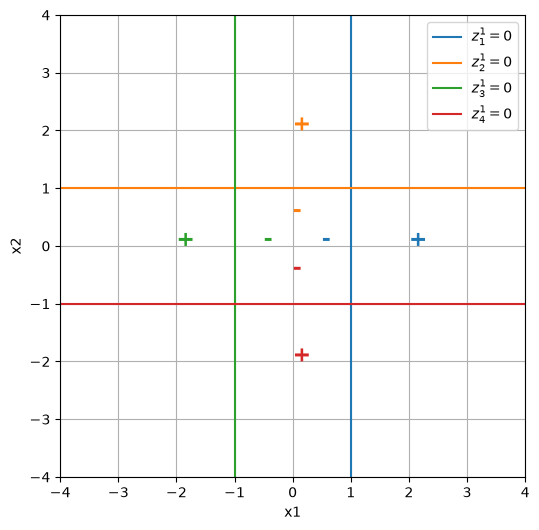

In [110]:
plt.figure(figsize=(6, 6))

# Plots
# z_1_1
x1 = np.ones(400)
x2 = np.linspace(-4, 4, 400)
plt.plot(x1, x2, label=r'$z_1^1=0$')

# z_1_2
x1 = np.linspace(-4, 4, 400)
x2 = np.ones(400)
plt.plot(x1, x2, label=r'$z_2^1=0$')

# z_1_3
x1 = np.ones(400) * (-1)
x2 = np.linspace(-4, 4, 400)
plt.plot(x1, x2, label=r'$z_3^1=0$')

# z_1_4
x1 = np.linspace(-4, 4, 400)
x2 = np.ones(400) * (-1)
plt.plot(x1, x2, label=r'$z_4^1=0$')

# Annotations
plt.text(2.0, 0, '+', color='#1f77b4', fontsize=16, fontweight='bold')
plt.text(0.5, 0, '-', color='#1f77b4', fontsize=16, fontweight='bold')

plt.text(0, 2.0, '+', color='#ff7f0e', fontsize=16, fontweight='bold')
plt.text(0, 0.5, '-', color='#ff7f0e', fontsize=16, fontweight='bold')

plt.text(-2.0, 0, '+', color='#2ca02c', fontsize=16, fontweight='bold')
plt.text(-0.5, 0, '-', color='#2ca02c', fontsize=16, fontweight='bold')

plt.text(0, -2.0, '+', color='#d62728', fontsize=16, fontweight='bold')
plt.text(0, -0.5, '-', color='#d62728', fontsize=16, fontweight='bold')

plt.xlim(-4, 4)
plt.ylim(-4, 4)

plt.xlabel("x1")
plt.ylabel("x2")

plt.grid()
plt.legend()
plt.show()

3.2.A) What is the shape of the decision boundary for a single unit?

<div align="center">
    <img src="../assets/homeworks/19_3_2_A.png" alt="19_3_2_A" style="border-radius: 10px" />
</div>

3.2.B) Enter a (2 x 4) matrix where each column represents a different input vector $([x_1,x_2]^T$), each of which is on the decision boundary for the first unit, that is, for which $(z_{1}^1=0$).

There are multiple possible answers.

<div align="center">
    <img src="../assets/homeworks/20_3_2_B.png" alt="20_3_2_B" style="border-radius: 10px" />
</div>

3.2.C) Consider the following input vectors: $x^{(1)} = [0.5, 0.5]^T$, $x^{(2)} = [0, 2]^T$, $x^{(3)} = [-3, 0.5]^T$. 

Enter a matrix where each column represents the outputs of the hidden units $(f(z_1^1), \dots, f(z_4^1))$ for each of the input vectors. You can use your diagram of decision boundaries.

<div align="center">
    <img src="../assets/homeworks/21_3_2_C.png" alt="21_3_2_C" style="border-radius: 10px" />
</div>

### 3.3) Network outputs

In our network above, the output layer with two softmax units is used to classify into one of two classes. For class 1, the first unit's output should be larger than the other unit's output, and for class 2, the second unit's output should be larger. This generalizes nicely to $k$ classes by using $k$ output units.

(We have previously examined addressing two-class classification problems using a single output unit with a sigmoid activation; this is another way to address them.)

Let's characterize the region in $x$-space where this network's output indicates the first class (that is, $a_1^2$ is larger) or indicates the second class (that is, $a_2^2$ is larger). Your diagram from the previous part will be useful here.

What is the output value of the neural network in each of the following cases? Write your answer for $a_i^2$ as expressions, you can use powers of $e$, for example, $e^2 + 1$; the exponents can be negative, $e^{-2} + 1$.

Case 1) For

$$
f(z_1^1)+f(z_2^1)+f(z_3^1)+f(z_4^1)=0
$$

<div align="center">
    <img src="../assets/homeworks/22_3_3_A.png" alt="22_3_3_A" style="border-radius: 10px" />
</div>

<div align="center">
    <img src="../assets/homeworks/23_3_3_B.png" alt="23_3_3_B" style="border-radius: 10px" />
</div>

In [ ]:
# Prediction
a_2_1 = np.exp(0)/(np.exp(0) + np.exp(2))
a_2_2 = np.exp(2)/(np.exp(0) + np.exp(2))

print(f"a_2_1 = {a_2_1}")
print(f"a_2_2 = {a_2_2}")

# Class 2 is predicted

a_2_1 = 0.11920292202211755
a_2_2 = 0.8807970779778824


<div align="center">
    <img src="../assets/homeworks/24_3_3_C.png" alt="23_3_3_C" style="border-radius: 10px" />
</div>

<div align="center">
    <img src="../assets/homeworks/25_3_3_D.png" alt="25_3_3_D" style="border-radius: 10px" />
</div>

<div align="center">
    <img src="../assets/homeworks/26_3_3_E.png" alt="26_3_3_E" style="border-radius: 10px" />
</div>

In [ ]:
# Prediction
a_2_1 = np.exp(1)/(np.exp(1) + np.exp(1))
a_2_2 = np.exp(1)/(np.exp(1) + np.exp(1))

print(f"a_2_1 = {a_2_1}")
print(f"a_2_2 = {a_2_2}")

# boundary

a_2_1 = 0.5
a_2_2 = 0.5


<div align="center">
    <img src="../assets/homeworks/27_3_3_F.png" alt="27_3_3_F" style="border-radius: 10px" />
</div>

<div align="center">
    <img src="../assets/homeworks/28_3_3_G.png" alt="28_3_3_G" style="border-radius: 10px" />
</div>

<div align="center">
    <img src="../assets/homeworks/29_3_3_H.png" alt="29_3_3_H" style="border-radius: 10px" />
</div>

In [113]:
# Prediction
a_2_1 = np.exp(3)/(np.exp(3) + np.exp(-1))
a_2_2 = np.exp(-1)/(np.exp(3) + np.exp(-1))

print(f"a_2_1 = {a_2_1}")
print(f"a_2_2 = {a_2_2}")

# Class 1 is predicted

a_2_1 = 0.9820137900379085
a_2_2 = 0.01798620996209156


<div align="center">
    <img src="../assets/homeworks/30_3_3_I.png" alt="30_3_3_I" style="border-radius: 10px" />
</div>

---